In [1]:

from langgraph.graph import MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

load_dotenv()
model = ChatOpenAI()

In [2]:
class ChatState(MessagesState):
  summary: str

In [3]:
def summarize_conversation(state: ChatState):
  existing_summary= state["summary"]

  if existing_summary:
    prompt = (f"Existing summary:\n{existing_summary}\n\n Extend the summary using the new conversation above.")
  else:
    prompt = "Summarize the converstaion above."

  message_for_summary = state["messages"] + [HumanMessage(content=prompt)]

  response = model.invoke(message_for_summary)

  message_to_remove = state["messages"][:-2]

  return {
    "summary": response.content,
    "messages": [RemoveMessage(id=m.id) for m in message_to_remove]
  }

In [5]:
def chat_node(state: ChatState):
  messages = []

  if state["summary"]:
    messages.append({
      "role" : "user",
      "content" : f"conversation summary: \n {state['summary']}"
    })
  
  messages.extend(state["messages"])

  print(messages)

  response = model.invoke(messages)

  return {"messages":[response]}

In [6]:
def should_summarize(state: ChatState):
  return len(state["messages"]) > 6

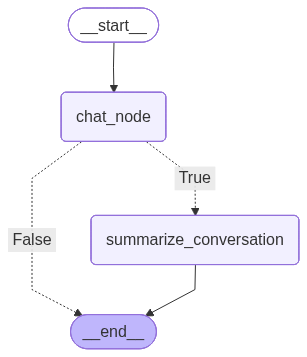

In [7]:
builder = StateGraph(ChatState)

builder.add_node("chat_node", chat_node)
builder.add_node("summarize_conversation", summarize_conversation)

builder.add_edge(START, "chat_node")
builder.add_conditional_edges(
  "chat_node",
  should_summarize,
  {
    True: "summarize_conversation",
    False: END
  }
)
builder.add_edge("summarize_conversation", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

graph

In [11]:
config = {"configurable":{"thread_id":"thread-1"}}

def run_turn(text: str):
  out = graph.invoke({"messages":HumanMessage(content=text), "summary":""}, config=config)
  return out

In [9]:

# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [12]:

run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='26231405-5f18-4892-8192-000b4e05172a')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics is the branch of physics that deals with the behavior and intera


In [13]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='26231405-5f18-4892-8192-000b4e05172a'), AIMessage(content='Quantum physics is the branch of physics that deals with the behavior and interactions of particles at the smallest scales, including subatomic particles like electrons and photons. It is based on the principles of quantum theory, which describes the surprising and often counterintuitive behavior of particles at the quantum level.\n\nSome key concepts in quantum physics include wave-particle duality, where particles can exhibit both wave-like and particle-like properties; superposition, where particles can exist in multiple states simultaneously; and entanglement, where particles can become interconnected in such a way that the state of one particle can instantly affect the state of another, regardless of the distance between them.\n\nQuantum physics has applications in many areas of science and technology, including quantum computing, quan

In [14]:
run_turn('What are some of Einstien"s famous work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='26231405-5f18-4892-8192-000b4e05172a'), AIMessage(content='Quantum physics is the branch of physics that deals with the behavior and interactions of particles at the smallest scales, including subatomic particles like electrons and photons. It is based on the principles of quantum theory, which describes the surprising and often counterintuitive behavior of particles at the quantum level.\n\nSome key concepts in quantum physics include wave-particle duality, where particles can exhibit both wave-like and particle-like properties; superposition, where particles can exist in multiple states simultaneously; and entanglement, where particles can become interconnected in such a way that the state of one particle can instantly affect the state of another, regardless of the distance between them.\n\nQuantum physics has applications in many areas of science and technology, including quantum computing, quan

In [15]:
run_turn('Explain special theory of relativity')
show_state()


[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='26231405-5f18-4892-8192-000b4e05172a'), AIMessage(content='Quantum physics is the branch of physics that deals with the behavior and interactions of particles at the smallest scales, including subatomic particles like electrons and photons. It is based on the principles of quantum theory, which describes the surprising and often counterintuitive behavior of particles at the quantum level.\n\nSome key concepts in quantum physics include wave-particle duality, where particles can exhibit both wave-like and particle-like properties; superposition, where particles can exist in multiple states simultaneously; and entanglement, where particles can become interconnected in such a way that the state of one particle can instantly affect the state of another, regardless of the distance between them.\n\nQuantum physics has applications in many areas of science and technology, including quantum computing, quan

In [16]:
run_turn('My name is Anupam Rana.')
show_state()

[HumanMessage(content='Explain special theory of relativity', additional_kwargs={}, response_metadata={}, id='3096976c-0037-4667-8f1c-b5b92302ee5f'), AIMessage(content="The special theory of relativity, developed by Albert Einstein in 1905, is a fundamental theory in physics that describes the relationship between space and time. The theory is based on two key principles:\n\n1. The principle of relativity: The laws of physics are the same in all inertial reference frames. In other words, observers moving at constant velocity relative to each other will all measure the same physical laws. This principle challenges the classical notion of absolute time and space.\n\n2. The constancy of the speed of light: In all inertial reference frames, the speed of light in a vacuum is constant and does not depend on the motion of the source or the observer. This principle contradicts the classical idea that the speed of light is additive with the velocity of the source or observer.\n\nFrom these two 

In [17]:
run_turn('who is einstien?')
show_state()

[HumanMessage(content='Explain special theory of relativity', additional_kwargs={}, response_metadata={}, id='3096976c-0037-4667-8f1c-b5b92302ee5f'), AIMessage(content="The special theory of relativity, developed by Albert Einstein in 1905, is a fundamental theory in physics that describes the relationship between space and time. The theory is based on two key principles:\n\n1. The principle of relativity: The laws of physics are the same in all inertial reference frames. In other words, observers moving at constant velocity relative to each other will all measure the same physical laws. This principle challenges the classical notion of absolute time and space.\n\n2. The constancy of the speed of light: In all inertial reference frames, the speed of light in a vacuum is constant and does not depend on the motion of the source or the observer. This principle contradicts the classical idea that the speed of light is additive with the velocity of the source or observer.\n\nFrom these two 

In [18]:
run_turn('what is my name?')
show_state()

[HumanMessage(content='Explain special theory of relativity', additional_kwargs={}, response_metadata={}, id='3096976c-0037-4667-8f1c-b5b92302ee5f'), AIMessage(content="The special theory of relativity, developed by Albert Einstein in 1905, is a fundamental theory in physics that describes the relationship between space and time. The theory is based on two key principles:\n\n1. The principle of relativity: The laws of physics are the same in all inertial reference frames. In other words, observers moving at constant velocity relative to each other will all measure the same physical laws. This principle challenges the classical notion of absolute time and space.\n\n2. The constancy of the speed of light: In all inertial reference frames, the speed of light in a vacuum is constant and does not depend on the motion of the source or the observer. This principle contradicts the classical idea that the speed of light is additive with the velocity of the source or observer.\n\nFrom these two 